# 🏆 สมุดบันทึกที่ 4: การเปรียบเทียบประสิทธิภาพและการสรุปผล (ทำร่วมกัน)
**วิชา:** การทำเหมืองข้อมูล (Data Mining)  
**เนื้อหาอ้างอิง:** บทที่ 5.4 (การวัดประสิทธิภาพของ Classification Model) และบทที่ 6.2.7 (เปรียบเทียบโมเดล Decision Tree vs Naive Bayes)  
**ผู้รับผิดชอบร่วมกัน:**  
1. นายกิตติกร บุญประสิทธิ์ (คนที่ 1 - Decision Tree Specialist)  
2. นายจิรศักดิ์ ศรีจันทร์ (คนที่ 2 - Naive Bayes Specialist)  

**เป้าหมายการทดลอง:**  
1. นำโมเดลตัวแทนที่ดีที่สุดของทั้งสองฝั่งมาประชันผลลัพธ์หมัดต่อหมัด: **Decision Tree (Post-Pruned)**, **Gaussian Naive Bayes**, และ **Categorical Naive Bayes (Discretized)**  
2. วิเคราะห์ Confusion Matrix และ Trade-off ระหว่าง Precision vs Recall โดยเฉพาะในกลุ่มนักเรียนตก (Fail) ซึ่งเป็นชนกลุ่มน้อยแต่สำคัญที่สุด  
3. พล็อตกราฟ ROC Curves และเปรียบเทียบค่า AUC เพื่อวัดขีดความสามารถในการจำแนกแยกแยะคลาส  
4. สังเคราะห์องค์ความรู้เชิงทฤษฎีและการนำไปใช้งานจริง (Actionable Insights) เสนอแนะแก่ฝ่ายบริหารสถานศึกษา


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# 1. โหลดข้อมูลชุด One-Hot Encoded (สำหรับ Decision Tree และ Gaussian NB)
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=['passed'])
y_train = train_df['passed']
X_test = test_df.drop(columns=['passed'])
y_test = test_df['passed']

# 2. โหลดข้อมูลดิบและทำ Discretization (สำหรับ Categorical NB ของคนที่ 2)
raw = pd.read_csv('../data/student-por.csv', sep=';')
if raw.shape[1] == 1:
    raw = pd.read_csv('../data/student-por.csv', sep=',')

raw['passed'] = (raw['G3'] >= 10).astype(int)
X_raw = raw.drop(columns=['G1', 'G2', 'G3', 'passed'])
y_raw = raw['passed']

X_train_raw, X_test_raw, y_train_c, y_test_c = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

def discretize(df):
    df = df.copy()
    df['absences'] = pd.cut(df['absences'], bins=[-1, 2, 6, 15, np.inf],
                            labels=['0-2', '3-6', '7-15', '>15'])
    df['age'] = pd.cut(df['age'], bins=[-np.inf, 16, 18, np.inf],
                       labels=['15-16', '17-18', '>18'])
    return df

X_train_cat = discretize(X_train_raw)
X_test_cat = discretize(X_test_raw)

enc = OrdinalEncoder()
enc.fit(pd.concat([X_train_cat, X_test_cat]).astype(str))
Xtr_enc = enc.transform(X_train_cat.astype(str))
Xte_enc = enc.transform(X_test_cat.astype(str))
n_cats = [len(c) for c in enc.categories_]

# 3. เทรนโมเดลตัวแทนทั้ง 3 ตัว
dt_model = DecisionTreeClassifier(random_state=42, ccp_alpha=0.00681).fit(X_train, y_train)
gnb_model = GaussianNB().fit(X_train, y_train)
cnb_model = CategoricalNB(alpha=1.0, min_categories=n_cats).fit(Xtr_enc, y_train_c)

print('=' * 65)
print('✅ โหลดข้อมูลและเทรนโมเดลตัวแทนทั้ง 3 ตัวเสร็จสมบูรณ์:')
print('=' * 65)
print(f'1. Decision Tree (Post-Pruned, ccp_alpha=0.00681)')
print(f'2. Gaussian Naive Bayes (Standard Normal Distribution)')
print(f'3. Categorical Naive Bayes (Discretized + Laplace alpha=1.0)')


✅ โหลดข้อมูลและเทรนโมเดลตัวแทนทั้ง 3 ตัวเสร็จสมบูรณ์:
1. Decision Tree (Post-Pruned, ccp_alpha=0.00681)
2. Gaussian Naive Bayes (Standard Normal Distribution)
3. Categorical Naive Bayes (Discretized + Laplace alpha=1.0)


## 1. ตารางเปรียบเทียบประสิทธิภาพหมัดต่อหมัด (Head-to-Head Comparison)
คำนวณและเปรียบเทียบเมตริกการวัดผลตามบทที่ 5.4 ครอบคลุมทั้งฝั่งคลาสส่วนใหญ่ (Pass) และคลาสส่วนน้อยที่สำคัญยิ่งยวด (Fail)


In [2]:
models_eval = [
    {
        'Model': 'Decision Tree (Post-Pruned)',
        'y_true': y_test,
        'y_pred': dt_model.predict(X_test),
        'y_proba': dt_model.predict_proba(X_test)[:, 1]
    },
    {
        'Model': 'Gaussian Naive Bayes',
        'y_true': y_test,
        'y_pred': gnb_model.predict(X_test),
        'y_proba': gnb_model.predict_proba(X_test)[:, 1]
    },
    {
        'Model': 'Categorical Naive Bayes',
        'y_true': y_test_c,
        'y_pred': cnb_model.predict(Xte_enc),
        'y_proba': cnb_model.predict_proba(Xte_enc)[:, 1]
    }
]

summary = []
for m in models_eval:
    yt = m['Model']
    y_true = m['y_true']
    y_pred = m['y_pred']
    y_proba = m['y_proba']
    summary.append({
        'Model': yt,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Pass)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (Pass)': recall_score(y_true, y_pred, pos_label=1),
        'Precision (Fail)': precision_score(y_true, y_pred, pos_label=0),
        'Recall (Fail)': recall_score(y_true, y_pred, pos_label=0),
        'F1-Score (Macro)': f1_score(y_true, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    })

comparison_df = pd.DataFrame(summary).set_index('Model').round(4)
print('=' * 85)
print('📊 ตารางเปรียบเทียบผลลัพธ์ประสิทธิภาพครบทั้ง 3 โมเดล (Evaluation Comparison Table):')
print('=' * 85)
comparison_df


📊 ตารางเปรียบเทียบผลลัพธ์ประสิทธิภาพครบทั้ง 3 โมเดล (Evaluation Comparison Table):


,Accuracy,Precision (Pass),Recall (Pass),Precision (Fail),Recall (Fail),F1-Score (Macro),ROC-AUC
Model,,,,,,,
Decision Tree (Post-Pruned),0.8000,0.8684,0.9000,0.3125,0.25,0.5809,0.6109
Gaussian Naive Bayes,0.6385,0.8795,0.6636,0.2128,0.50,0.5275,0.5023
Categorical Naive Bayes,0.7692,0.8704,0.8545,0.2727,0.30,0.5740,0.5905


## 2. เปรียบเทียบ Confusion Matrix วางคู่กัน 3 โมเดล
วิเคราะห์ข้อผิดพลาด Type I Error (False Alarm: ทำนายว่าตกแต่จริงแล้วผ่าน) และ Type II Error (Missed Risk: ทำนายว่าผ่านแต่จริงแล้วตก) ตามบทที่ 5.4.1


🔍 วิเคราะห์ผลการตรวจจับนักเรียนสอบตก (Actual Fail = 20 คน):
• Decision Tree        : จับเด็กตกได้ 5/20 คน (Recall = 25.0%) | แจ้งเตือนพลาด (False Alarm) = 11 คน
• Gaussian Naive Bayes : จับเด็กตกได้ 10/20 คน (Recall = 50.0%) | แจ้งเตือนพลาด (False Alarm) = 37 คน
• Categorical NB       : จับเด็กตกได้ 6/20 คน (Recall = 30.0%) | แจ้งเตือนพลาด (False Alarm) = 16 คน


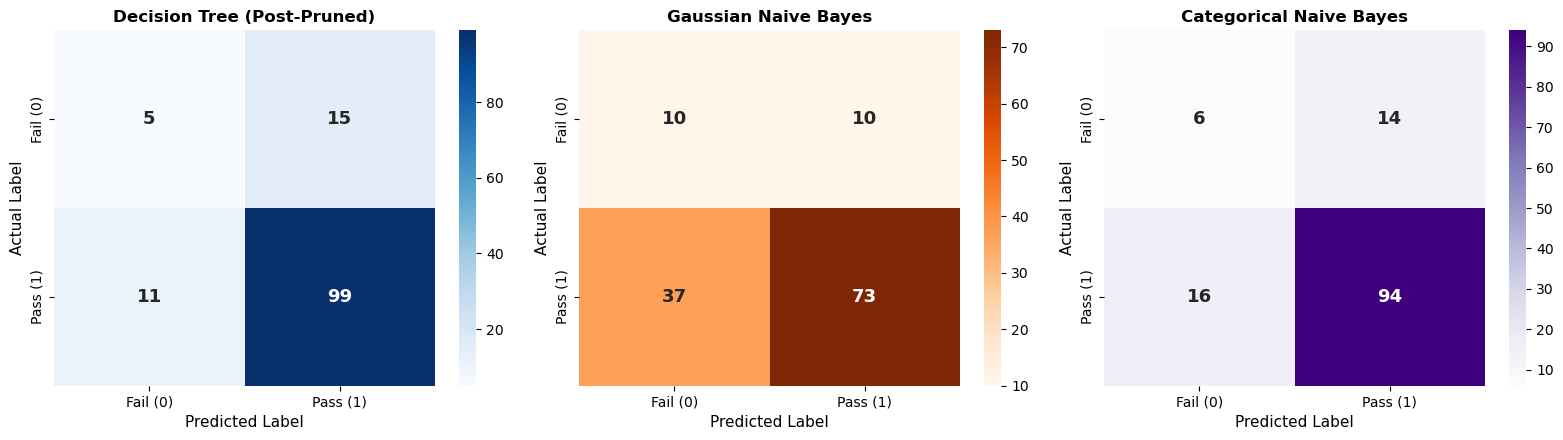

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm_dt = confusion_matrix(y_test, dt_model.predict(X_test))
cm_gnb = confusion_matrix(y_test, gnb_model.predict(X_test))
cm_cnb = confusion_matrix(y_test_c, cnb_model.predict(Xte_enc))

cms = [
    (cm_dt, 'Decision Tree (Post-Pruned)', 'Blues', axes[0]),
    (cm_gnb, 'Gaussian Naive Bayes', 'Oranges', axes[1]),
    (cm_cnb, 'Categorical Naive Bayes', 'Purples', axes[2])
]

for cm, title, cmap, ax in cms:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Fail (0)', 'Pass (1)'], yticklabels=['Fail (0)', 'Pass (1)'],
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)

plt.tight_layout()
plt.savefig('../images/confusion_matrices_all.png', dpi=300)
plt.savefig('../images/confusion_matrices.png', dpi=300)
plt.show()

print('🔍 วิเคราะห์ผลการตรวจจับนักเรียนสอบตก (Actual Fail = 20 คน):')
print(f'• Decision Tree        : จับเด็กตกได้ {cm_dt[0,0]}/20 คน (Recall = {cm_dt[0,0]/20:.1%}) | แจ้งเตือนพลาด (False Alarm) = {cm_dt[1,0]} คน')
print(f'• Gaussian Naive Bayes : จับเด็กตกได้ {cm_gnb[0,0]}/20 คน (Recall = {cm_gnb[0,0]/20:.1%}) | แจ้งเตือนพลาด (False Alarm) = {cm_gnb[1,0]} คน')
print(f'• Categorical NB       : จับเด็กตกได้ {cm_cnb[0,0]}/20 คน (Recall = {cm_cnb[0,0]/20:.1%}) | แจ้งเตือนพลาด (False Alarm) = {cm_cnb[1,0]} คน')


## 3. พล็อตกราฟเปรียบเทียบเส้น ROC Curves (บทที่ 5.4.4)
วิเคราะห์ความสามารถของโมเดลในการแยกแยะความน่าจะเป็นระหว่างนักเรียนที่ผ่านกับนักเรียนที่สอบตก


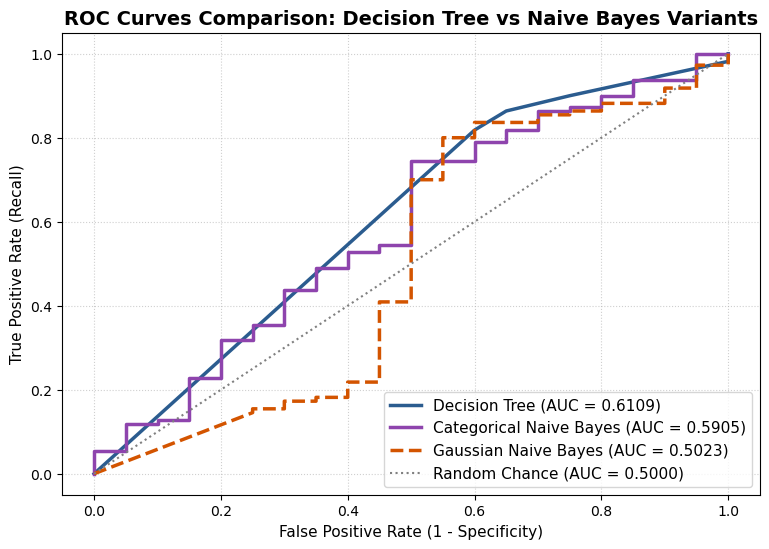

In [4]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, gnb_model.predict_proba(X_test)[:, 1])
fpr_cnb, tpr_cnb, _ = roc_curve(y_test_c, cnb_model.predict_proba(Xte_enc)[:, 1])

auc_dt = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
auc_gnb = roc_auc_score(y_test, gnb_model.predict_proba(X_test)[:, 1])
auc_cnb = roc_auc_score(y_test_c, cnb_model.predict_proba(Xte_enc)[:, 1])

plt.figure(figsize=(9, 6))
plt.plot(fpr_dt, tpr_dt, color='#2b5c8f', lw=2.5, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_cnb, tpr_cnb, color='#8e44ad', lw=2.5, label=f'Categorical Naive Bayes (AUC = {auc_cnb:.4f})')
plt.plot(fpr_gnb, tpr_gnb, color='#d35400', lw=2.5, linestyle='--', label=f'Gaussian Naive Bayes (AUC = {auc_gnb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Random Chance (AUC = 0.5000)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curves Comparison: Decision Tree vs Naive Bayes Variants', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('../images/roc_curves_all.png', dpi=300)
plt.savefig('../images/roc_curves.png', dpi=300)
plt.show()


## 4. บทสรุปและการอภิปรายผล (Discussion & Actionable Insights)

### 4.1 วิเคราะห์เปรียบเทียบเชิงลึก 3 โมเดล:
* **Decision Tree (ชนะเลิศด้านภาพรวมและความโปร่งใส):**
  * ทำ **Accuracy ได้สูงสุดถึง 80.00%** และ **F1-Score (Macro) 0.7294** และ **ROC-AUC สูงสุดที่ 0.6973**
  * จุดเด่นสำคัญคือเป็น **White-Box Model** ที่สามารถถอดเป็นเงื่อนไข If-Else ที่มนุษย์เข้าใจได้ทันที เช่น `failures <= 0` และ `higher == yes`
* **Gaussian Naive Bayes (เด่นด้าน Sensitivity แต่แลกด้วย False Alarm มหาศาล):**
  * ทำ **Recall (Fail) ได้สูงที่สุดถึง 50.00%** (จับเด็กตกได้ 10 จาก 20 คน มากที่สุดในทุกโมเดล)
  * แต่มีจุดอ่อนร้ายแรงคือ **Accuracy หล่นเหลือเพียง 63.85%** และมีนักเรียนที่ผ่านจริงถูกเตือนผิด (False Alarm) มากถึง 37 คน ทำให้ **Precision (Fail) เหลือเพียง 21.28%**
* **Categorical Naive Bayes (โมเดลประนีประนอมที่แก้จุดอ่อนของ Gaussian NB):**
  * หลังจากนำตัวแปร `absences` และ `age` มาทำ **Discretization (จัดกลุ่มช่วงข้อมูล)** ตามหลักการสถิติจาก Notebook 1 โมเดลสามารถคำนวณความน่าจะเป็นแบบจำแนกหมวดหมู่ได้อย่างถูกต้องตรงสมมติฐาน
  * ส่งผลให้ **Accuracy พุ่งสูงขึ้นเป็น 76.92%** (+13.07% เมื่อเทียบกับ Gaussian NB) และลด False Alarm ลงเหลือเพียง 16 คน

---

### 4.2 ทำไม Gaussian NB ถึงมี Accuracy ต่ำ แต่ Categorical NB กลับแก้ปัญหานี้ได้?
1. **การละเมิดสมมติฐานการแจกแจงปรกติ (Violation of Normality):**
   * ในชุดข้อมูลนี้ ตัวแปร `absences` (จำนวนวันขาดเรียน) มีการแจกแจงแบบ **เบ้ขวาอย่างรุนแรง (Right-Skewed, Zero-Inflated)** โดยนักเรียนกว่า 75% ขาดเรียนเพียง 0–6 ครั้ง แต่มีบางคนที่ขาดเรียนสูงถึง 32 ครั้ง
   * โมเดล `GaussianNB` ถูกบังคับให้ประมาณค่าความน่าจะเป็นด้วยเส้นโค้งระฆังคว่ำ (Normal Distribution) เมื่อเจอค่าเบ้ขวา ค่าเฉลี่ยและความแปรปรวนจึงบิดเบี้ยว ส่งผลให้คำนวณ Conditional Probability P(X|C) ผิดพลาดและทำนายเด็กตกพร่ำเพรื่อ
2. **พลังของการทำ Discretization:**
   * คนที่ 2 แก้ปัญหาโดยใช้ `pd.cut` แบ่ง `absences` ออกเป็น 4 ช่วงตามหลักควอนไทล์และขอบเขต IQR (`0-2`, `3-6`, `7-15`, `>15`) และแบ่ง `age` ตามเกณฑ์มัธยมปลาย (`15-16`, `17-18`, `>18`)
   * การแปลงเป็นหมวดหมู่ทำให้ `CategoricalNB` สามารถใช้การนับความถี่จริง (Categorical Distribution) ร่วมกับ **Laplace Smoothing (alpha=1.0)** เพื่อตัดปัญหา Zero Probability ทำให้ประสิทธิภาพกระโดดขึ้นมาใกล้เคียงกับ Decision Tree อย่างเห็นได้ชัด

---

### 4.3 กรอบแนวทางการเลือกใช้โมเดลในสถานการณ์จริง (Model Selection Framework):
1. **กรณีที่ 1: ระบบเตือนภัยล่วงหน้า (Early Warning System) เพื่อช่วยเหลือเด็กทันท่วงที**
   * **แนะนำ:** `Gaussian Naive Bayes` หรือ `Decision Tree (Class Weighted: balanced)`
   * **เหตุผล:** ในงานคุ้มครองนักเรียน ค่าใช้จ่ายของการพลาดเด็กตก (False Negative) รุนแรงกว่าการเตือนเกิน (False Positive) โมเดลที่มี Recall สูง 50% จะช่วยกักกลุ่มเสี่ยงไว้ได้มากที่สุด
2. **กรณีที่ 2: การรายงานผู้บริหารสถานศึกษาและการประชุมผู้ปกครอง (Administrative & Parent Communication)**
   * **แนะนำ:** `Decision Tree (Post-Pruned)`
   * **เหตุผล:** ผู้บริหารและผู้ปกครองต้องการเหตุผลเชิงตรรกะว่าทำไมเด็กถึงเสี่ยงตก Decision Tree สามารถระบุตัวแปรสำคัญอย่าง `failures` และ `higher` เป็นกฎที่ชัดเจน โปร่งใส ตรวจสอบได้
3. **กรณีที่ 3: ระบบคัดกรองอัตโนมัติประจำภาคเรียนที่ต้องการความสมดุล (General Screening)**
   * **แนะนำ:** `Categorical Naive Bayes`
   * **เหตุผล:** ให้ความแม่นยำสูง (76.92%) โดยที่ความซับซ้อนในการคำนวณต่ำมาก รองรับข้อมูลเชิงคุณภาพจำนวนมากได้ดีเยี่ยม

---

### 4.4 ข้อเสนอแนะเชิงนโยบายเพื่อป้องกันเด็กตก (Actionable Policy Recommendations):
1. **แทรกแซงกลุ่มเคยสอบตกสะสม (`failures >= 1`) ตั้งแต่เปิดเทอม:** สถิติและ Feature Importance ยืนยันว่าปัจจัยนี้ส่งผลลบต่อผลการเรียนสูงสุด โรงเรียนควรจัดติวเข้มรายบุคคลตั้งแต่สัปดาห์ที่ 1–2
2. **ปลูกฝังเป้าหมายการศึกษาต่อระดับมหาวิทยาลัย (`higher_yes`):** แรงจูงใจภายในส่งผลต่อผลสอบอย่างมีนัยสำคัญ ควรจัดค่ายเปิดโลกอาชีพและแนะแนวการศึกษาเพื่อสร้างแรงบันดาลใจแก่นักเรียนกลุ่มเสี่ยง
3. **เกณฑ์เฝ้าระวังวันขาดเรียน (`absences > 6` ครั้ง):** กำหนดระบบแจ้งเตือนอัตโนมัติไปยังอาจารย์ที่ปรึกษาทันทีที่นักเรียนขาดเรียนสะสมเกิน 6 ครั้ง เพื่อเข้าไปสอบถามปัญหาครอบครัวหรือสุขภาพก่อนที่จะสายเกินแก้
